---
# Computergestützte Datenauswertung
**Institut für Experimentelle Teilchenphysik (ETP)** <br>
**Institut für Theorie der Kondensierten Materie (TKM)** <br>
Prof. Dr. Jan Kieseler (ETP), Dr. Joscha Ahäuser (ETP) <br>
Dr. Thorsten Chwalek (ETP), Dr. Andreas Poenicke (TKM) <br>
[ILIAS-Seite zum Kurs](https://ilias.studium.kit.edu/ilias.php?baseClass=ilrepositorygui&cmdNode=xs:mo&cmdClass=ilobjcoursegui&ref_id=2891557&item_ref_id=0) <br>
Sommersemester 2026 – Blatt 05 <br>
Abgabe: Montag, 8.06.2026, oder Dienstag, 9.06.2026

---

Werbung 

![RocketScience3](RocketScience3.png)

Werbung Ende 
# Wichtig: Anmeldung im Campussystem
Um die Übung als erfolgreich bestanden anerkannt zu bekommen, müssen Sie sich bis zur Abgabe des letzten Blattes im [Campussytem](https://campus.studium.kit.edu/exams/registration.php) für die Leistung anmelden!
Die Voraussetzung zum Bestehen ist das erfolgreiche Bearbeiten von mindestens einer Aufgabe in vier der fünf Übungsblätter 1-5 und das erfolgreiche Testat von Übungsblatt 6.<br>
Anmeldebeginn:	1.06.26 08:00<br>
Anmeldeschluss:	12.06.26 14:00<br>
Abmeldungen möglich bis 19.06.26 14:00

---

---
- Die [erste Aufgabe](#Aufgabe1) zeigt Ihnen an einem ausführlichen Beispiel, wie Sie das Werkzeug [`kafe2`](https://kafe2.readthedocs.io) verwenden können, um die Anpassung verlässlich und ohne viel Aufwand durchzuführen. 
Dabei wird Ihnen die Paramaterschätzung einmal "vorgeführt" und anschließen haben Sie die Möglichkeit, das Ergebnis aus der Aufgabe vom letzten Übungsblatt zu reproduzieren.
- In der [zweiten Aufgabe](#Aufgabe2) beschäftigen Sie sich mit einer typischen Herausforderung, die Ihnen bereits in der Vorlesung vorgestellt wurde: Korrelationen zwischen Anpassungsparametern.
In dieser Aufgabe werden Sie die Korrelationen visualisieren und einen Ansatz zum Umgang mit Korrelationen ausarbeiten.

---
# Aufgabe 1: Anpassung von Modellen an Daten mit `kafe2` <a id="Aufgabe1"></a>
---
Obwohl sich viele <mark>Anpassungsprobleme</mark> auch analytisch lösen lassen, werden in der Praxis Software-Werkzeuge eingesetzt, die die Verwaltung von Daten, Modellen und das Durchführen der eigentlichen Anpassung mit numerischen Methoden bewerkstelligen.
Ein solches Werkzeug ist [`kafe2`](http://kafe2.readthedocs.io). 
Dieses Werkzeug ist am KIT entworfen worden und wird hier ständig weiter entwickelt.
Mit der Zeit wurde zu `kafe2` einiges an Funktionalität hinzugefügt. Damit bietet `kafe2` ein breites <mark>Spektrum von Methoden für die Parameterschätzung</mark> an, auch über den Bedarf des physikalischen Praktikums hinaus.
Lassen Sie sich jedoch noch nicht durch das Paket abschrecken, sondern üben Sie sich in der Anwendung der wichtigsten Funktionen durch das Beispiel in dieser Aufgabe.
Bei Gelegenheit können Sie gerne durch die [Online-Dokumentation](https://kafe2.readthedocs.io/en/latest/parts/beginners_guide.html) stöbern und sich einen Überblick über die Funktionalität von `kafe2` verschaffen.

Ziel dieser Aufgabe ist, dass Sie anhand des Beispiels und wenigen Veränderungen des Beispielcodes die Parameterschätzung aus dem letzten Übungsblatt wiederholen können. 

**Beispiel:**<br>
1. `kafe2` bietet eine Struktur, die auf Python-Klassen beruht. Diese Struktur ermöglicht es Ihnen an vielen Stellen die Parameterschätzung (ab hier *Fit* genannt) zu beeinflussen. In der Vorlesung haben Sie die "Wrapper-Funktionen" `kafe2.xy_fit()` und `kafe2.plot()` kennengelernt. Hier werden Sie direkt mit den zugrundeliegen Klassen `kafe2.XYFit` und `kafe2.Plot` und deren Methoden arbeiten.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from kafe2 import XYFit, Plot


2. An erster Stelle steht immer das Einlesen Ihrer gemessenen Daten. 
In diesem Beispiel gehen Sie den kurzen Weg und tragen "Messpunkte" direkt in die Sequenzen `x` und `y` ein.
In der Anwendung in physikalischen Praktikum werden Sie hier `NumPy`, `PhyPraKit` oder Ähnliches verwenden, um die Daten direkt aus einer Datei auszulesen, die Ihr Messcomputer ausgibt.
Im Beispiel nehmen Sie an, dass `x` mit unendlicher Genauigkeit gemessen wurde und nicht mit einer Unsicherheit behaftet ist.
Auf `y` nehmen Sie die Unsicherheiten in `yerr` an.
Die Sequenzen `x`, `y` und `yerr` können Sie praktisch in jeder Form (Liste, *Numpy*-Array, ...) angeben oder ein `kafe2.XYContainer`-Objekt verwenden.
Mehr dazu finden Sie in der Dokumentation von `kafe2`.

In [5]:
# "Einlesen" der Daten
x = [.05, 0.36, 0.68, 0.80, 1.09, 1.46, 1.71, 1.83, 2.44, 2.09, 3.72, 4.36, 4.60]
y = [0.35, 0.26, 0.52, 0.44, 0.48, 0.55, 0.66, 0.48, 0.75, 0.70, 0.75, 0.80, 0.90]
yerr = [0.06, 0.07, 0.05, 0.05, 0.07, 0.07, 0.09, 0.1, 0.11, 0.1, 0.11, 0.12, 0.1]

3. Das Modell, welches Sie an die Daten anpassen (oder *fitten*) wollen, können Sie selbstständig als Funktion definieren.
Es bietet sich an, dass das erste Argument den $x$-Werten entspricht, die Sie vorgeben und fitten wollen.
Alle weiteren Argumente der Funktionen sind die freien Parameter, die Sie fitten.
In diesem Beispiel passen Sie den vorgegebenen Daten ein Polynom zweiten Grades an, welches Sie in der Funktion `poly2()` definieren.
Alternativ bietet `kafe2` selbst einige einfache Funktionen (wie Polynome), die im nächsten Schritt übergeben können.
Zur besseren Veranschaulichung definieren Sie hier jedoch die Funktion selbst.

In [6]:
# Definition des anzupassenden Modells
def poly2(x, a=1.0, b=0.0, c=0.0):
    return a * x**2 + b * x + c

4. Jetzt können Sie den Fit selbst zusammenstellen, indem Sie ein `XYFit`-Objekt erzeugen, welches auf jeden Fall zwei Argumente benötigt.
    - Sie müssen dem Argument `xy_data` die Daten, die Sie fitten wollen, übergeben. Ein Objekt der Klasse `kafe2.XYContainer` könnten Sie hier direkt verwenden. Sie überspringen diesen Schritt und übergeben die Daten direkt als verschachtelte Liste in der Reihenfolge $x$, $y$.
    - Dem Argument `model_function` übergeben Sie die Funktion (ohne Argumente), die das Modell beschreibt, welches gefittet werden soll.

    Sie erzeugen ein Objekt der Klasse `XYFit` mit dem Namen `fit`, auf die Sie im folgenden noch zugreifen werden und woran Sie noch weitere Anpassungen vornehmen werden.

In [8]:
# Definition des Fits
fit = XYFit(xy_data=[x, y], model_function=poly2)

5. An dieser Stelle können Sie nun die Unsicherheiten der Messungen an das Objekt `fit` übergeben.
Dazu können Sie die Methode `add_error()` der Klasse `XYFit` verwenden.
(Anmerkung: Sie hätten diesen Schritt auch direkt mit dem `XYContainer` durchführen können.)
Die Methode `add_error()` übernimmt mit dem Argument `axis` die Achse, an der die Unsicherheiten angenommen werden.
Sie können also `x` (oder 0) oder `y` (oder 1) angeben.
Dem Argument `err_val` übergeben Sie den Wert der Unsicherheit.
Sie können hier entweder eine Zahl angeben, wenn Sie davon ausgehen, dass für jeden Messwert die gleiche Unsicherheit vorliegt, oder eine Sequenz mit der gleichen Länge wie die Achse, an der die Unsicherheit anliegt.
Weitere praktische Argumente an dieser Stelle sind auch `correlation` (Zahl) und `relative` (`True` oder `False`).
Im physikalischen Praktikum werden Sie häufiger die Situation vorfinden, dass an Geräten ein relativer Fehler angegeben wird (z. B. 10%). In diesem Fall würden  Sie `err_val=0.1, relative=True` setzen. Es könnte auch eine Korrelation zwischen beispielsweise Strom- und Spannungsmessung angegeben werden.
(Anmerkung: Sie können einer Achse auch mehrere Unsicherheiten aus unterschiedlichen Quellen mit `add_error()` hinzufügen.)

In [9]:
# Hinzufügen der Unsicherheiten
fit.add_error(axis='y', err_val=yerr)

'VBTUsXPA'

6. Der nächste Schritt im Beispiel ist rein optional und setzt einen schönen Ausdruck für die Darstellung der Modellfunktion im späteren Plot.

In [10]:
# Optional: LaTeX Ausdrücke für den Plot festlegen
fit.assign_parameter_latex_names(a='A', b='B', c="C")
fit.assign_model_function_latex_expression(r"{a}\,x^2 + {b}\,x+{c}")

7. Mit der Methode `XYFit.do_fit()` führen Sie nun den Fit selbst durch.
Sie müssen sich an dieser Stelle keine Gedanken über den Minimierungsprozess des Maßes oder der Berechnung und Propagation der Unsicherheiten machen.
Diese Schritte werden für Sie im Hintergrund erledigt.

In [11]:
# Fit ausführen
fit.do_fit()

/home/julian/.local/lib/python3.10/site-packages/kafe2/fit/_base/fit.py:1091: UserWarning: Intial values and step sizes for one or more fit parameters are not well-defined: ['b', 'c']. For better convergence set initial values != 0, set initial step sizes via parameter_errors, or limit, fix, or constrain the parameters.
  warnings.warn(


{'did_fit': True,
 'cost': -55.620695130027215,
 'ndf': 10,
 'goodness_of_fit': np.float64(9.645644119732582),
 'gof/ndf': np.float64(0.9645644119732582),
 'chi2_probability': np.float64(0.4721124336361239),
 'parameter_values': OrderedDict([('a', np.float64(-0.01651975201978295)),
              ('b', np.float64(0.19323223725795224)),
              ('c', np.float64(0.3154625676125633))]),
 'parameter_cov_mat': array([[ 0.00016287, -0.00072041,  0.0004335 ],
        [-0.00072041,  0.0034873 , -0.00231133],
        [ 0.0004335 , -0.00231133,  0.00209543]]),
 'parameter_errors': OrderedDict([('a', np.float64(0.012762126326052867)),
              ('b', np.float64(0.0590533971496688)),
              ('c', np.float64(0.04577592133940343))]),
 'parameter_cor_mat': array([[ 1.        , -0.95589386,  0.7420362 ],
        [-0.95589386,  1.        , -0.85502941],
        [ 0.7420362 , -0.85502941,  1.        ]]),
 'asymmetric_parameter_errors': None}

8. Die Methode `XYFit.report()` gibt Ihnen ausführliche Informationen darüber, wie der Fit durchgelaufen ist. 
Dieser Schritt ist optional, aber sehr hilfreich, wenn Sie herausfinden wollen, warum Ihr Fit gerade nicht funktioniert hat.

In [12]:
# Optional: Ausführlicher Bericht über den Fit
fit.report()

########
# Data #
########

    X Data
    0.05  
    0.36  
    0.68  
    0.8   
    1.09  
    1.46  
    1.71  
    1.83  
    2.44  
    2.09  
    3.72  
    4.36  
    4.6   

    Y Data  Y Data Error  Y Data Correlation Matrix               
    ======  ============  ========================================
    0.35    0.06          [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    0.26    0.07          [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    0.52    0.05          [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    0.44    0.05          [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    0.48    0.07          [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
    0.55    0.07          [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
    0.66    0.09          [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
    0.48    0.1           [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
    0.75    0.11          [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
    0.7     0.1           [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
    0.75    0

9. Der letzte Schritt ist das Darstellen des Ergebnisses und ist ebenfalls optional.
Sie erzeugen hier ein Objekt der Klasse `Plot` und übergeben den erfolgreich durchgeführten Fit. 
Mit der Methode `Plot.plot()` führen Sie die Darstellung des Ergebnisses aus.
An dieser Stelle können Sie viele Optionen zur Visualisierung übergeben, lesen Sie dazu auch gerne in der Dokumentation weiter.

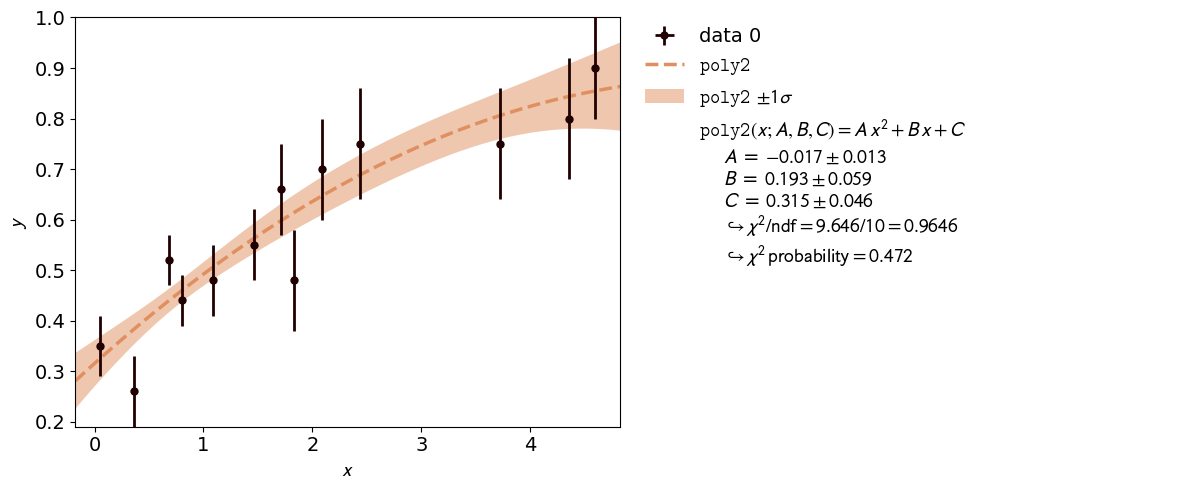

In [13]:
# Optional: Darstellung des Fits im kafe2-Stil
plot = Plot(fit)
plot.y_label = "$y$"
plot.x_label = "$x$"
plot.plot()

plt.show()

**Wiederholung: Güte der Anpassung:** <br>
In der grafischen Darstellung von `kafe2` und in der Ausgabe von `XYFit.do_fit()` finden Sie die Begriffe <mark>$\chi^2/\mathrm{ndf}$ und $\chi^2\ \mathrm{probability}$.<\mark>
Diese <mark>Größen sind ein Maß für die Qualität des Fit<\mark>. Sie geben auch Hinweise darauf wie einfach Sie den Fit mit einem anderen Datensatz aus der gleichen Grundmenge wiederholen könnten.
Dabei gelten folgende Faustregeln:
- Werte von $\chi^2/\mathrm{ndf}\approx 1$ bzw. $\chi^2\ \mathrm{probability}\sim 0.4$ zeigen einen sehr guten Fit.
- Werte von $\chi^2/\mathrm{ndf}\ll 1$ bzw. $\chi^2\ \mathrm{probability}\to 1$ deuten darauf hin, dass das Modell sich sehr stark an die gegebenen Daten angepasst hat und "zu gut passt". Würden Sie andere Daten aus derselben Grundmenge fitten, wird dieser Fit voraussichtlich kein gutes Ergebnis erzielen können. Mögliche Lösungen:
    - Vielleicht haben Sie die <mark>Unsicherheit zu groß geschätzt </mark>- Überprüfen Sie nochmal Ihre Berechnungen.
    - Das Modell hat zu <mark>viele Freiheitsgrade</mark> und kann sich einzelnen Abweichungen anpassen. Wählen Sie ein einfacheres Modell.
- Für Werte von $\chi^2/\mathrm{ndf}\gg 1$ bzw. $\chi^2\ \mathrm{probability}\to 0$) kann das Modell die Daten nicht genügend gut beschreiben. Mit diesem Modell werden Sie kaum eine statistisch sinnvolle Aussage über die Daten treffen können. Mögliche Lösungen:
    - Vielleicht haben Sie die <mark>Unsicherheit zu klein geschätzt</mark> - Überprüfen Sie nochmal Ihre Berechnungen.
    - Das Modell hat zu <mark>wenige Freiheitsgrade</mark> und kann sich den Daten nur schlecht anpassen. Wählen Sie ein anderes Modell.

**Arbeitsanweisung:**<br>
Führen Sie die <mark>Parameterschätzung</mark> der Dämpfungskonstante $D$ der gemessenen Resonanzkurve aus [Aufgabe 1](#Aufgabe1) hier nochmal durch.
Verwenden Sie hierfür `kafe2`, indem Sie das Beispiel von oben an wenigen Stellen anpassen.

In [16]:
# Resonanzfunktion
def resonance(eta, D):
    return 1/np.sqrt((1 - eta*eta)**2 + (2*eta*D)**2)

# Gemesse Datenpunkt
etam = np.array([0.10, 0.30, 0.50, 0.70, 0.90, 1.10, 1.30, 1.50, 1.70, 1.90, 2.10])
Am = np.array([0.97, 0.92, 1.12, 1.09, 1.36, 1.17, 0.76, 0.54, 0.47, 0.41, 0.36])

# Absolute Unsicherheit auf die gemessene Amplitude
Aerr = 0.1

########
# Data #
########

    X Data
    0.1   
    0.3   
    0.5   
    0.7   
    0.9   
    1.1   
    1.3   
    1.5   
    1.7   
    1.9   
    2.1   

    Y Data  Y Data Error  Y Data Correlation Matrix         
    ======  ============  ==================================
    0.97    0.1           [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    0.92    0.1           [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    1.12    0.1           [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
    1.09    0.1           [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
    1.36    0.1           [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
    1.17    0.1           [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
    0.76    0.1           [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
    0.54    0.1           [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
    0.47    0.1           [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
    0.41    0.1           [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
    0.36    0.1           [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]

#########
# Model #
#########

    Model Func

/home/julian/.local/lib/python3.10/site-packages/kafe2/fit/_base/fit.py:1091: UserWarning: Intial values and step sizes for one or more fit parameters are not well-defined: ['D']. For better convergence set initial values != 0, set initial step sizes via parameter_errors, or limit, fix, or constrain the parameters.
  warnings.warn(


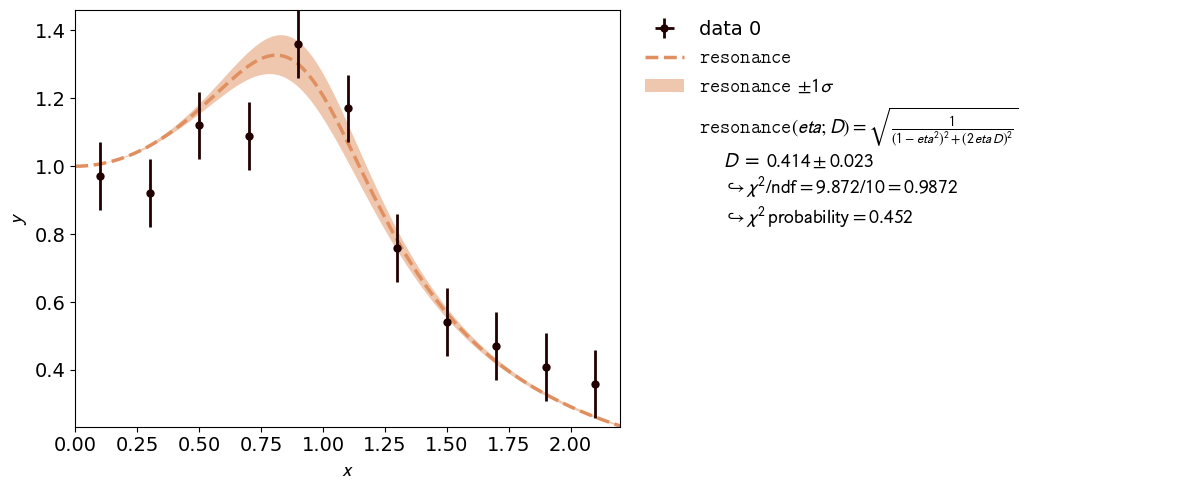

In [25]:
# Definition des Fits
fit = XYFit(xy_data=[etam, Am], model_function=resonance)
# Hinzufügen der Unsicherheiten
fit.add_error(axis='y', err_val=Aerr)

# D muss einen wert bekommen der Sinnig ist basierenmd auf experiment

#latex zeichen
fit.assign_parameter_latex_names(eta='eta',D='D')
#fit.assign_model_function_latex_expression(
    # Wichtig: Doppelte Klammern für LaTeX-Befehle, einfache für die kafe2-Parameter!
fit.assign_model_function_latex_expression(
    r"\sqrt{{\frac{{1}}{{(1 - eta^2)^2 + (2\,eta\,D)^2}}}}"
)


# Fit ausführen
fit.do_fit()
# Optional: Ausführlicher Bericht über den Fit
fit.report()
# Darstellung des Fits im kafe20Stil
plot = Plot(fit)
plot.x_label = "$x$"
plot.y_label = "$y$"
plot.plot()
plot.show()



---
# Aufgabe 2: Korrelation von Fit-Parametern <a id="Aufgabe2"></a>
---

In der Vorlesung haben Sie analytisch die Parameterschätzung für eine Ausgleichsgerade $\lambda(x;\mathbf{a})=a_0+a_1 x$ ausgerechnet.
Im letzten Schritt ist Ihnen dabei aufgefallen, dass die Parameter $a_0$ und $a_1$ stark antikorreliert sind.
Sie können sich das veranschaulichen, indem Sie sich vorstellen, dass Sie die Gerade, die bei $x=0$ beginnt und zu positiven $x$-Werten läuft, an der Stelle $x=0$ festhalten und wie einen Stab bewegen können.
Wenn Sie nun die Steigung anpassen (den Stab also kippen), bewegt sich auch gleichzeitig der Ordinatenabschnitt (Ihre Hand), wenn Sie dieselben Datenpunkte durchlaufen möchten.

![Correlation](Correlation.png)

Um dies näher zu studieren, schauen Sie sich in dieser Aufgabe eine grafische Darstellung der Korrelationen in Form von Kovarianz-Ellipsen an.

**Arbeitsanweisung:**<br>
Lesen Sie Daten aus der Datei `data.txt` ein und <mark>fitten Sie eine Gerade der Form $\lambda(x;\mathbf{a})=a_0+a_1 x$ an die Daten<\mark>.
Beachten Sie dabei die Angabe der Unsicherheit der Messwerte in der Datei.
Stellen Sie die <mark>Kovarianz-Ellipse</mark mithilfe von `kafe2` grafisch dar.

**Hinweis:**<br>
Sie können zur Darstellung der Kovarianz-Ellipse die Klasse `kafe2.ContoursProfiler` nutzen. Diese benötigt als Parameter ein Objekt der Klasse `XYFit` von `kafe2`.
`ContoursProfiler`-Objekte besitzen die Methode `plot_profiles_contours_matrix()`, mit der Sie das Ergebnis grafisch darstellen können.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from kafe2 import  XYContainer, XYFit, Plot,ContoursProfiler

In [32]:
# Definition des einfachen linearen Modells
f_linear = lambda x, a, b: a + x * b

In [33]:
# Einlesen der Daten
data = np.loadtxt('data.txt', float)
x, y = data.T
y_err = 1

########
# Data #
########

    X Data
    10.0  
    11.0  
    12.0  
    13.0  
    14.0  
    15.0  
    16.0  
    17.0  
    18.0  
    19.0  
    20.0  

    Y Data  Y Data Error  Y Data Correlation Matrix         
    ======  ============  ==================================
    9.46    1.0           [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    9.71    1.0           [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    11.72   1.0           [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
    11.93   1.0           [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
    14.61   1.0           [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
    14.47   1.0           [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
    15.48   1.0           [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
    15.43   1.0           [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
    20.56   1.0           [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
    20.54   1.0           [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
    19.57   1.0           [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]

#########
# Model #
#########

    Model Func

/home/julian/.local/lib/python3.10/site-packages/kafe2/fit/_base/fit.py:1091: UserWarning: Intial values and step sizes for one or more fit parameters are not well-defined: ['a', 'b']. For better convergence set initial values != 0, set initial step sizes via parameter_errors, or limit, fix, or constrain the parameters.
  warnings.warn(


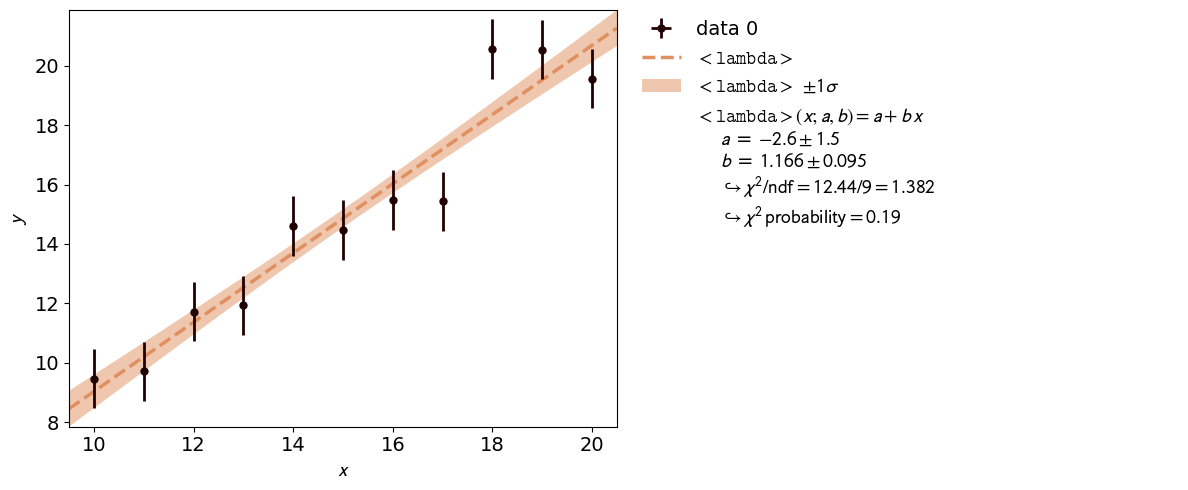

In [35]:
# Durchführung des Fits
fit = XYFit(xy_data=[x, y], model_function=f_linear)

fit.add_error(axis='y', err_val=y_err)

#latex zeichen
fit.assign_parameter_latex_names(x='x',a='a', b='b')
#fit.assign_model_function_latex_expression(
    # Wichtig: Doppelte Klammern für LaTeX-Befehle, einfache für die kafe2-Parameter!
fit.assign_model_function_latex_expression(
    r"a+b\,x"
)


# Fit ausführen
fit.do_fit()
# Optional: Ausführlicher Bericht über den Fit
fit.report()
# Darstellung des Fits im kafe20Stil
plot = Plot(fit)
plot.x_label = "$x$"
plot.y_label = "$y$"
plot.plot()
plot.show()

# Darstellen des Ergebnisses


In der Vorlesung wurde Ihnen auch direkt verraten, wie Sie diese Korrelation vermeiden können: Sie verschieben die $x$-Werte um ihren (gewichteten) Mittelwert: $\epsilon(x;\mathbf{s})=s_0+s_1 (x-\overline{x})$.

**Arbeitsanweisung:**<br>
Führen Sie obigen Geradenfit noch einmal durch, verwenden Sie jedoch $\epsilon(x;\mathbf{s})=s_0+s_1 (x-\overline{x})$ als lineares Modell.
Betrachten Sie erneut die Kovarianz-Ellipse der freien Fitparameter.
Welche Korrelation der Parameter $s_0$ und $s_1$ beobachten Sie und warum?

**Hinweis:**<br>
Argumentieren Sie z. B. mit der oben eingeführten Analogie mit dem Stab in der Hand.

In [ ]:
# Definition des neuen linearen Modells


In [ ]:
# Durchführung des Fits


# Darstellen des Ergebnisses
